In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.set_option("display.max_columns", None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [6]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    orders.groupby("purchase_month")
    .size()
    .reset_index(name="order_count")
)

print(monthly_orders.head())

  purchase_month  order_count
0        2016-09            4
1        2016-10          324
2        2016-12            1
3        2017-01          800
4        2017-02         1780


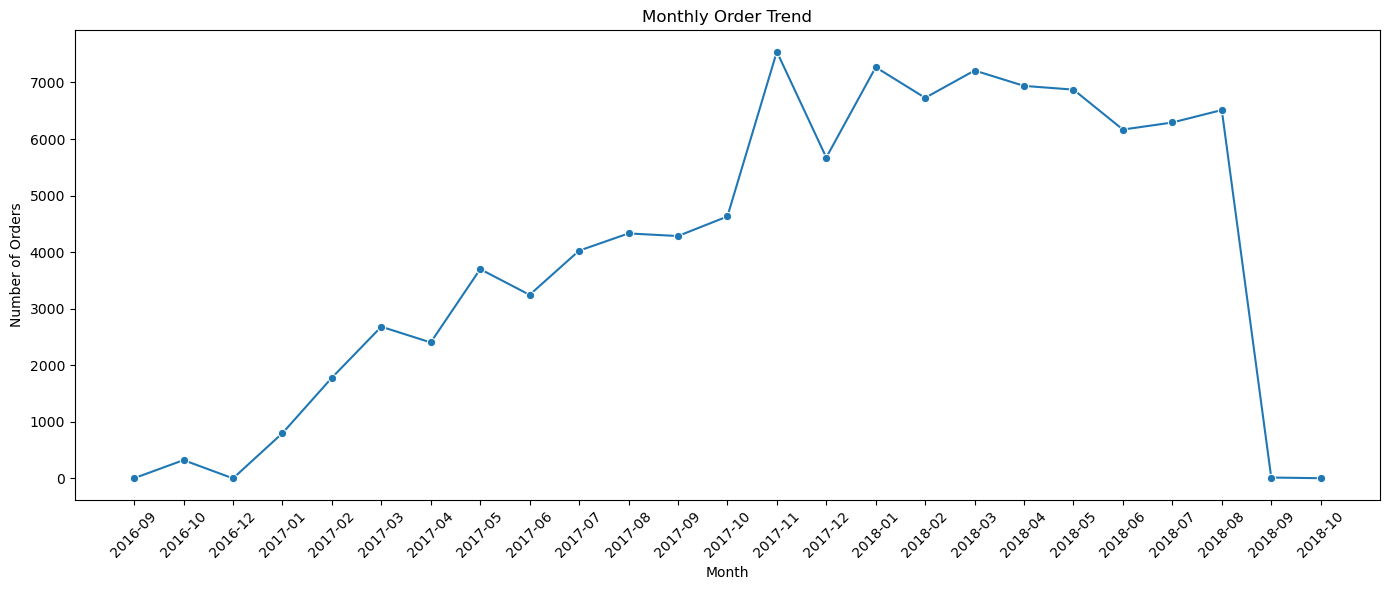

In [7]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_orders,
    x="purchase_month",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

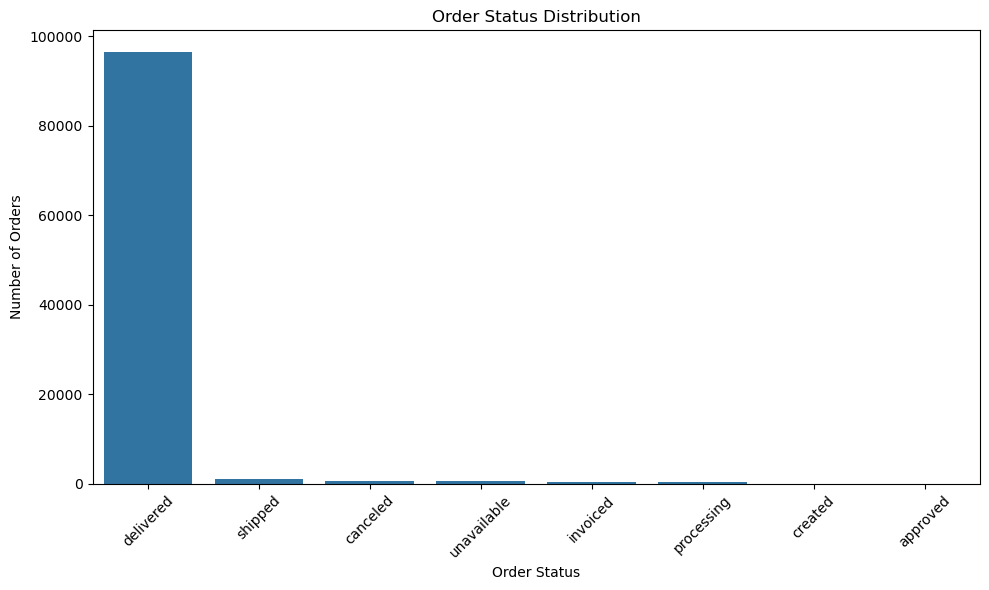

In [8]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
products_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_sales = order_items.merge(
    products_category[
        ["product_id", "product_category_name_english"]
    ],
    on="product_id",
    how="left"
)

category_sales_summary = (
    category_sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(category_sales_summary)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


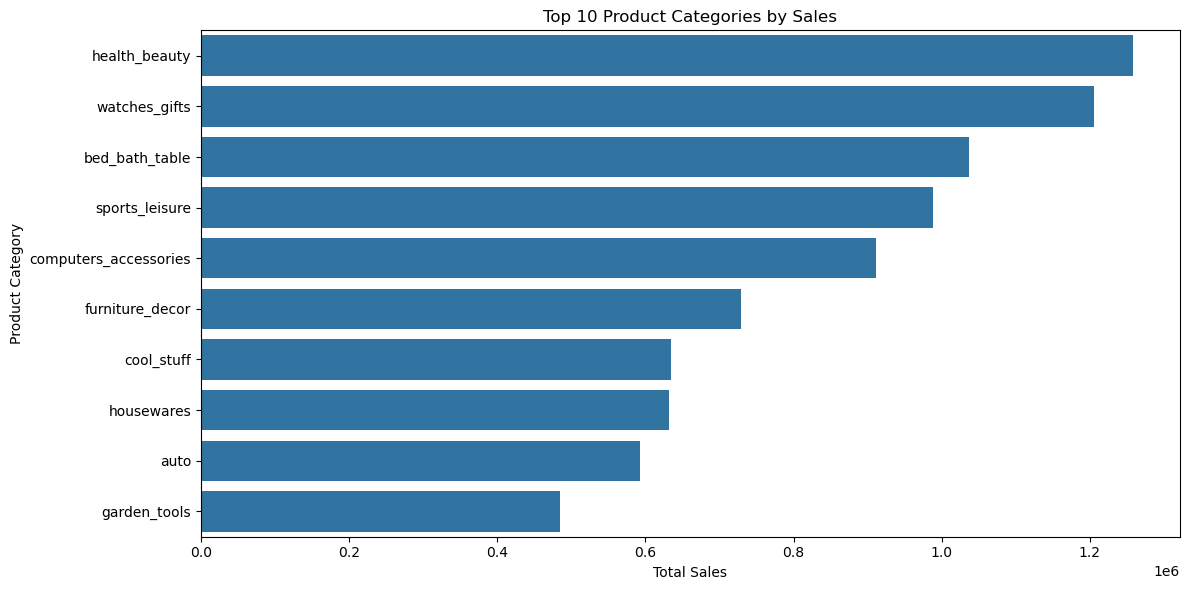

In [10]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_sales_summary.values,
    y=category_sales_summary.index
)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.tight_layout()

plt.show()

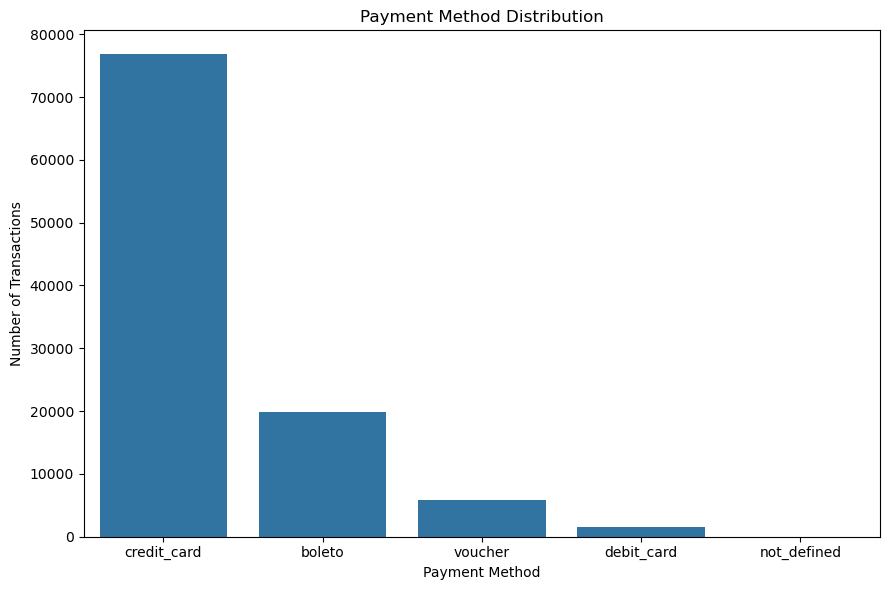

In [11]:
payment_counts = payments["payment_type"].value_counts()

plt.figure(figsize=(9, 6))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

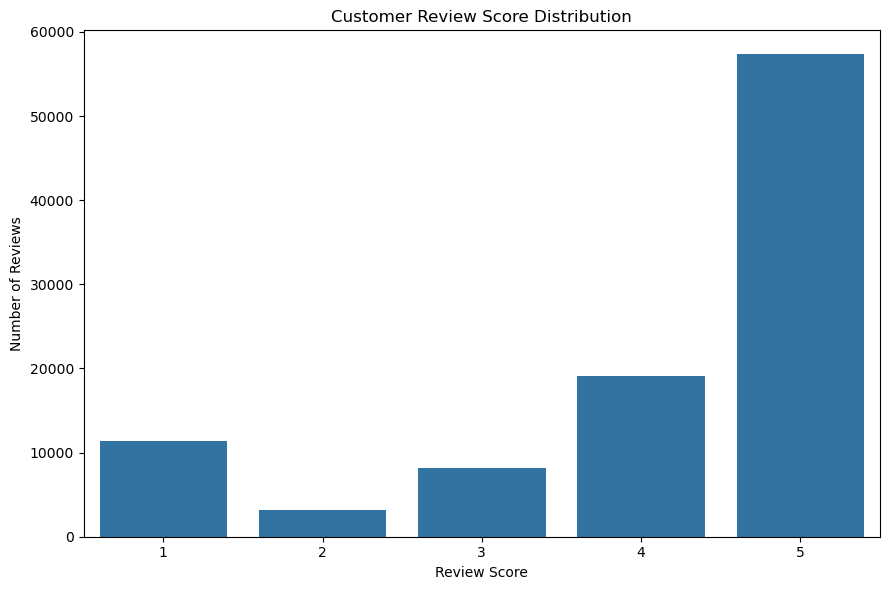

In [12]:
review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=review_counts.index,
    y=review_counts.values
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [13]:
order_sales = (
    order_items
    .groupby("order_id")
    .agg(
        total_sales=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
)

print(order_sales.head())

                           order_id  total_sales  total_freight
0  00010242fe8c5a6d1ba2dd792cb16214        58.90          13.29
1  00018f77f2f0320c557190d7a144bdd3       239.90          19.93
2  000229ec398224ef6ca0657da4fc703e       199.00          17.87
3  00024acbcdf0a6daa1e931b038114c75        12.99          12.79
4  00042b26cf59d7ce69dfabb4e55b4fd9       199.90          18.14


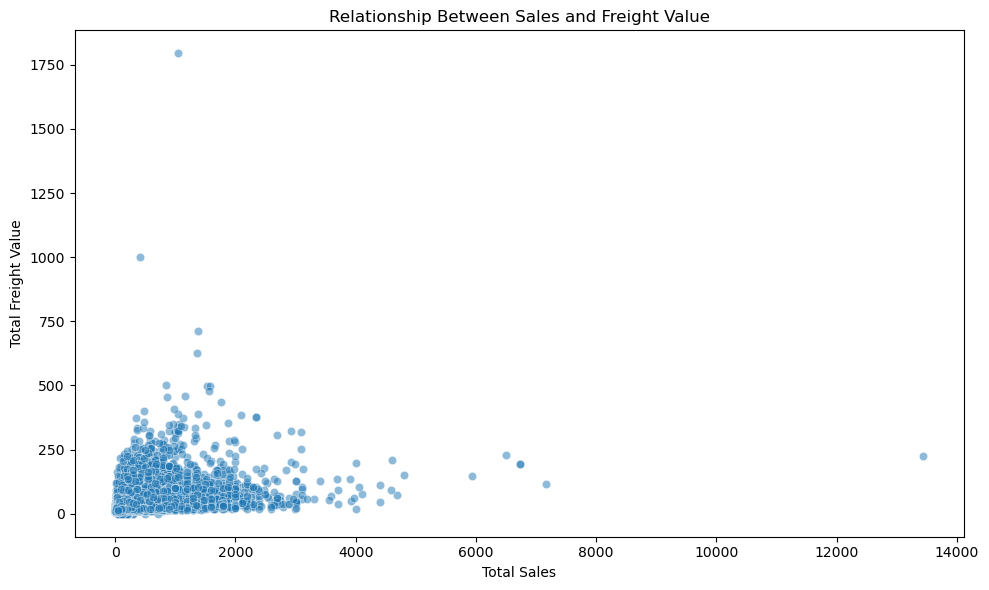

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=order_sales,
    x="total_sales",
    y="total_freight",
    alpha=0.5
)

plt.title("Relationship Between Sales and Freight Value")
plt.xlabel("Total Sales")
plt.ylabel("Total Freight Value")

plt.tight_layout()
plt.show()

In [15]:
delivery_data = orders[
    orders["order_status"] == "delivered"
].copy()
delivery_data["delivery_delay_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_estimated_delivery_date"]
).dt.days

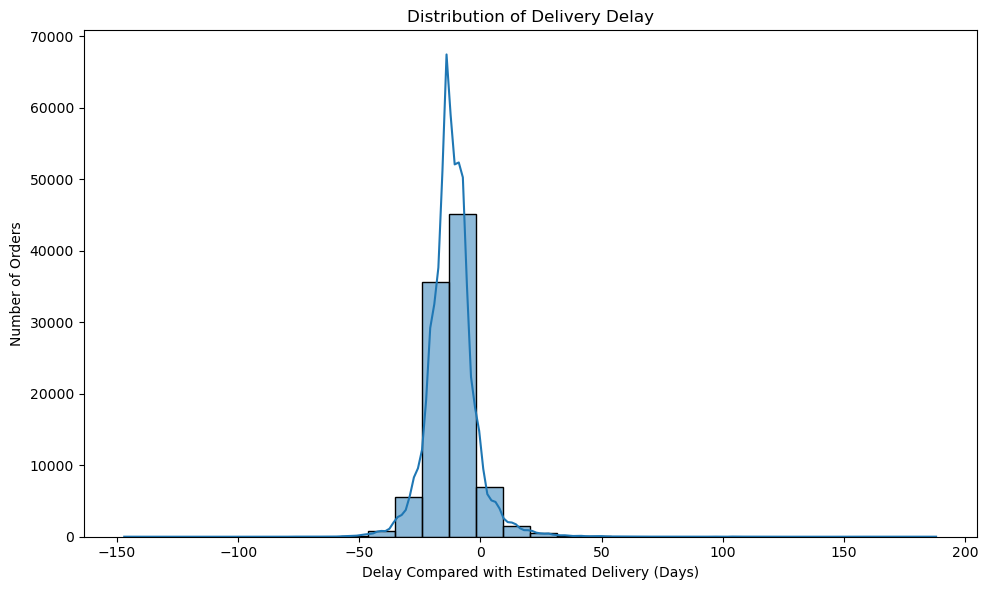

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=delivery_data,
    x="delivery_delay_days",
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay Compared with Estimated Delivery (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()